# Tutorial: collecting construction-site imagery

This notebook walks through the two steps of [A Framework for Semi-automatic Collection of Temporal Satellite Imagery for Analysis of Dynamic Regions](https://openaccess.thecvf.com/content/ICCV2021W/LUAI/papers/Motlagh_A_Framework_for_Semi-Automatic_Collection_of_Temporal_Satellite_Imagery_for_ICCVW_2021_paper.pdf) (ICCVW 2021):

1. **extract** every OpenStreetMap construction chain in a region and recover its true start/end dates and boundary tags, then
2. **gather** RGB / NIR chips across each chain's construction window.

Everything below runs against the `cssic` package (`pip install -e ".[dev,notebook]"`), uses the ohsome API for history and Planetary Computer STAC for imagery, and needs **no credentials**.

Original authors: Nicholas Kashani Motlagh, Aswathnarayan Radhakrishnan, Jim Davis (Ohio State University), and Roman Ilin (AFRL/RYAP). Point of contact for this fork: Nick ([@nmotlagh](https://github.com/nmotlagh)). CLI equivalents are given for every step; there is no GUI on purpose.

## Setup

`Workspace` owns the on-disk layout: `temp/snapshots/` for cached daily snapshots and `output/collection/` for the extracted collection. CLI: `cssic setup`.

In [1]:
from cssic import Credentials, ExtractConfig, GatherConfig, Workspace, load_poly, polygon_bounds

ws = Workspace()
ws.setup()
print(ws.snapshot_dir, ws.collection_dir)

temp/snapshots output/collection


To start over: `ws.reset_extract()` deletes the collection and per-chain folders (CLI `cssic reset-extract`), `ws.reset_images()` deletes only downloaded chips (CLI `cssic reset-images`).

In [2]:
# ws.reset_extract()
# ws.reset_images()

## Step 1: extract construction chains

`ExtractConfig` validates everything up front: `start` must be on or after 2015-06-22 (Sentinel-2's first day) and `end` more than 10 days in the past (exactly 10 days ago is rejected).

`poly/campus.poly` is an approximate box around the Ohio State University Columbus campus, for the demo only; `poly/osu.poly` is the real campus boundary (OSM relation 306632). Any [Osmosis `.poly`](https://wiki.openstreetmap.org/wiki/Osmosis/Polygon_Filter_File_Format) works — the search is by bounding box, but the result is clipped to the polygon.

In [3]:
cfg = ExtractConfig(
    start="2023-01-01",
    end="2023-03-01",
    poly="poly/campus.poly",
    backend="ohsome",  # or "osmium" with region="ohio-internal.osh.pbf"
)
region = load_poly(cfg.poly)
bbox = polygon_bounds(region)
bbox

(-83.042, 39.9935, -83.0075, 40.0165)

`build_chains` is the paper algorithm and talks only to the `HistorySource` protocol, so the ohsome and osmium backends are interchangeable. It walks backward from `start` for each chain's true start date, forward from `end` for its true end date, links chains across OSM id changes, and ranks the **previous tag** / **final tag** by IOU confidence.

Expect several minutes on a cold cache: one full-history query for the construction ways, then one neighbourhood snapshot query per chain boundary (the day before a start, the day after an end). Snapshots are cached under `temp/snapshots/` and always kept, so re-runs replay from disk. CLI: `cssic extract -s 2023-01-01 -e 2023-03-01 --poly poly/campus.poly`.

In [4]:
from cssic.chains import build_chains
from cssic.history import get_history_source

history = get_history_source("ohsome", cache_dir=ws)
completed, wip = build_chains(history, cfg, bbox=bbox, progress=None)
print(f"{len(completed)} completed chains, {len(wip)} still under construction")

23 completed chains, 4 still under construction


Each row is one construction chain: `chain_id`, `start`, `end`, `constr_tag` (`landuse` or `building`), the boundary tags `prev_tag` / `final_tag`, and the chain's bounding-box polygon.

In [5]:
collection_gdf = completed.to_gdf()
collection_gdf

,chain_id,start,end,constr_tag,prev_tag,final_tag,geometry
0,way-693909168-3,2019-06-02,2023-07-10,landuse,NO TAG FOUND,NO TAG FOUND,"POLYGON ((-83.00958 40.0003, -83.00958 40.0022..."
1,way-693909170-4,2019-06-02,2023-07-10,building,NO TAG FOUND,building=university,"POLYGON ((-83.00986 40.00142, -83.00986 40.002..."
2,way-696751176-5,2019-06-13,2023-02-19,landuse,NO TAG FOUND,leisure=pitch,"POLYGON ((-83.02456 40.01333, -83.02456 40.014..."
3,way-768967361-7,2020-02-02,2023-05-22,landuse,NO TAG FOUND,NO TAG FOUND,"POLYGON ((-83.01022 40.01285, -83.01022 40.013..."
4,way-768967362-8,2020-02-02,2023-05-22,building,NO TAG FOUND,building=apartments,"POLYGON ((-83.01025 40.01287, -83.01025 40.013..."
5,way-770472412-9,2020-02-07,2023-06-26,building,NO TAG FOUND,building=university,"POLYGON ((-83.00715 39.99897, -83.00715 39.999..."
6,way-770536887-10,2020-02-08,2026-03-06,landuse,NO TAG FOUND,NO TAG FOUND,"POLYGON ((-83.02015 39.99234, -83.02015 39.995..."
7,way-792945470-11,2020-04-18,2024-05-22,building,NO TAG FOUND,NO TAG FOUND,"POLYGON ((-83.01507 39.99445, -83.01507 39.994..."
8,way-810271578-12,2020-06-01,2023-11-06,landuse,landuse=grass,NO TAG FOUND,"POLYGON ((-83.03428 40.00326, -83.03428 40.006..."
9,way-810610967-13,2020-06-02,2023-02-06,landuse,NO TAG FOUND,landuse=commercial,"POLYGON ((-83.01343 40.01401, -83.01343 40.014..."


Save the collection as GeoPackage + GeoJSON + Shapefile under `output/collection/`, and write `output/{chain_id}/info.txt` (`start,end,prev_tag,final_tag,minx,miny,maxx,maxy`) for each chain.

In [6]:
ws.save_collection(collection_gdf)
ws.create_dataset(collection_gdf)

23

<Axes: >

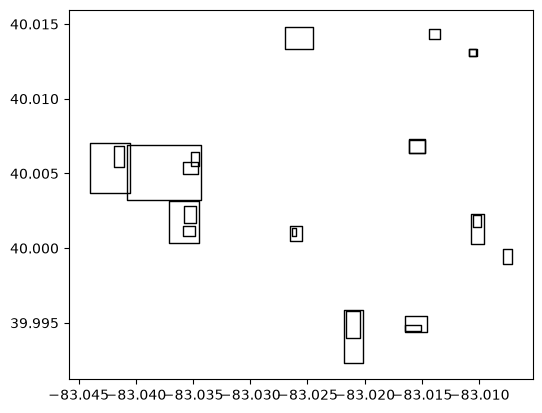

In [7]:
collection_gdf.plot(edgecolor="black", facecolor="none")

What the land became after construction:

<BarContainer object of 9 artists>

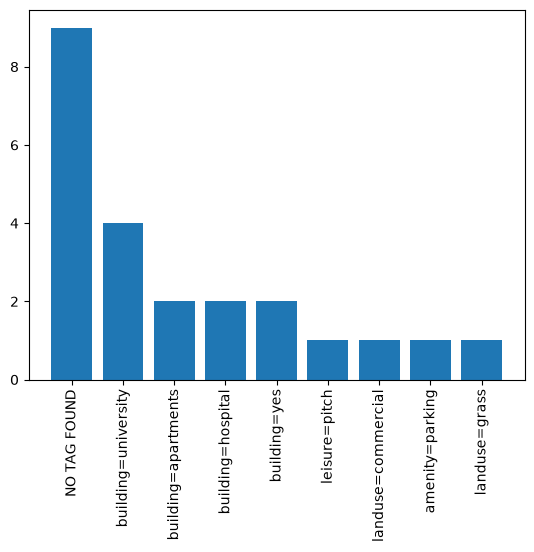

In [8]:
import matplotlib.pyplot as plt

histogram = collection_gdf["final_tag"].value_counts()
plt.xticks(rotation=90)
plt.bar(histogram.index, histogram.values)

## Step 2: gather imagery

`GatherConfig` picks the source and the sampling. `num_images` is any `n >= 1`, or `-1` for every available acquisition; from `n >= 2` up both endpoints of the construction window are sampled, while `n = 1` samples the start. `padding` is an area scale factor on the bounding box (center-invariant, `1` = the exact box).

`source="stac"` reads Sentinel-2 L2A from Planetary Computer and needs no key. `"s"` uses the Copernicus Data Space Process API (`SH_CLIENT_ID` / `SH_CLIENT_SECRET`), `"p"` places Planet PSScene orders (`PLANET_API_KEY` or `planet auth login`) — both read `.env` through `Credentials.from_env()`. Do not paste secrets into this notebook.

In [9]:
gather_cfg = GatherConfig(
    source="stac",  # "stac", "s" / "sentinel", or "p" / "planet"
    num_images=3,
    padding=2,
    rgb=True,
    nir=True,
    verbose=True,
    max_cloud_cover=80,
)
credentials = Credentials.from_env()
print("Planet key set:", bool(credentials.planet_api_key))
print("Sentinel Hub credentials set:", credentials.has_sentinel_hub)

Planet key set: False
Sentinel Hub credentials set: False


`run_gather` samples the dates, pads each chain's box, fetches the chips and writes them to `output/{chain_id}/images/{planet|sentinel}/{rgb|nir}/{YYYY-MM-DD}.png`. CLI: `cssic gather -s stac --rgb --nir -n 3`.

For Planet this places orders instead of downloading; re-run with `download_planet=True` (CLI `--download`) once they succeed.

In [10]:
from cssic.cli import run_gather

run_gather(gather_cfg, credentials, ws)

	2023-07-13 S2A_MSIL2A_20230713T161901_R040_T17TLE_20241121T055044: site cloud 0.00 (SCL)
	picked S2A_MSIL2A_20230713T161901_R040_T17TLE_20241121T055044 (2023-07-13) at 0.00 cloud over the site
way-693909168-3: no acquisition between 2019-06-02 and 2019-06-08


way-693909168-3: wrote output/way-693909168-3/images/sentinel/rgb/2021-06-23.png


way-693909168-3: wrote output/way-693909168-3/images/sentinel/nir/2021-06-23.png


way-693909168-3: wrote output/way-693909168-3/images/sentinel/rgb/2023-07-13.png


way-693909168-3: wrote output/way-693909168-3/images/sentinel/nir/2023-07-13.png
way-693909168-3: wrote 2 of 3 requested samples


...

	2025-07-24 S2A_MSIL2A_20250724T162711_R040_T17TLE_20250725T005716: site cloud 1.00 (SCL)


	2025-07-27 S2B_MSIL2A_20250727T161829_R040_T17TLE_20250727T202049: site cloud 1.00 (SCL)
	picked S2A_MSIL2A_20250724T162711_R040_T17TLE_20250725T005716 (2025-07-24) at 1.00 cloud over the site
way-1077541390-0: no acquisition between 2024-01-16 and 2024-01-22
way-1077541390-0: SKIPPED blank RGB for 2022-07-13
way-1077541390-0: wrote output/way-1077541390-0/images/sentinel/nir/2022-07-13.png


way-1077541390-0: wrote output/way-1077541390-0/images/sentinel/rgb/2025-07-24.png


way-1077541390-0: wrote output/way-1077541390-0/images/sentinel/nir/2025-07-24.png
way-1077541390-0: wrote 2 of 3 requested samples
Wrote 99 chip(s) under output


0

Look at what came back for the first chain:

way-693909168-3 ['2021-06-23.png', '2023-07-13.png']


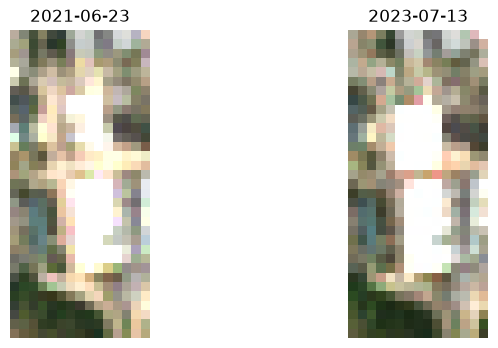

In [11]:
from PIL import Image

chain_id = str(collection_gdf.iloc[0]["chain_id"])
chips = sorted(ws.images_dir(chain_id, "sentinel", "rgb").glob("*.png"))
fig, axes = plt.subplots(1, max(len(chips), 1), figsize=(4 * max(len(chips), 1), 4))
axes = [axes] if len(chips) < 2 else list(axes)
for ax, chip in zip(axes, chips, strict=False):
    ax.imshow(Image.open(chip))
    ax.set_title(chip.stem)
    ax.axis("off")
print(chain_id, [chip.name for chip in chips])

## Where things land

```
output/collection/collection.{gpkg,geojson,shp}
output/{chain_id}/info.txt
output/{chain_id}/images/{planet|sentinel}/{rgb|nir}/{YYYY-MM-DD}.png
temp/snapshots/                cached ohsome/osmium snapshots
temp/order_log.txt             outstanding Planet orders
```

Planet RGB may also write `{date}_mask.png` (alpha / unusable pixels) and Planet NIR `{date}_udm.tif`. With `num_images=-1`, days with no scene get `{date}_empty.png`.